# Random Forest — classificação dos estados do jogo da velha

Amanda Wilmsen e Kamilah Santos.

Este experimento utiliza uma floresta aleatória para reconhecer as quatro classes.
Compara A1 e A2 nos mesmos conjuntos físicos dos demais classificadores. Execute
as células na ordem, a partir da raiz do projeto ou da pasta deste notebook.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from threadpoolctl import threadpool_limits
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Configuração do experimento

Comparamos as mesmas amostras em duas representações: **A1**, com as nove casas numéricas
(`b=0`, `x=1`, `o=-1`), e **A2**, com 15 características derivadas. Nesta última, as posições
ocupadas são nove indicadores binários, um por casa. As demais características são contagens
de X e O, alinhamentos com duas marcas, casas vazias e próximo turno hipotético.
A semente 42 identifica a configuração reproduzível do experimento.

In [2]:
SEED = 42
RAIZ = next(
    (pasta for pasta in [Path.cwd(), *Path.cwd().parents]
     if (pasta / "dataset/processado/abordagem_1/treino.csv").is_file()),
    None,
)
if RAIZ is None:
    raise FileNotFoundError("Execute o notebook dentro da pasta deste projeto.")
BASE = RAIZ / "dataset/processado"

CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
abordagens = {"abordagem_1": "A1 (tabuleiro)", "abordagem_2": "A2 (características)"}

figuras = {}

## 2. Leitura dos conjuntos preparados

Carregamos os CSVs de treino, validação e teste, separados fisicamente na preparação dos dados.
`X` contém as características e `y` contém o rótulo `estado`. Excluímos `id_tabuleiro`, que serve
para auditoria, e `estado`, que é a resposta a ser prevista, das entradas do classificador.
As divisões são compartilhadas por todos os algoritmos.

In [3]:
dados = {}
for ab in abordagens:
    d = {}
    for conjunto, sufixo in [("treino", "train"), ("validacao", "val"), ("teste", "test")]:
        df = pd.read_csv(f"{BASE}/{ab}/{conjunto}.csv")
        d[f"ids_{sufixo}"] = df["id_tabuleiro"]
        d[f"y_{sufixo}"] = df["estado"].values
        d[f"X_{sufixo}"] = df.drop(columns=["id_tabuleiro", "estado"])
    dados[ab] = d

for ab in abordagens:
    print(abordagens[ab])
    print("  X_train:", dados[ab]["X_train"].shape, " y_train:", dados[ab]["y_train"].shape)
    print("  X_val:  ", dados[ab]["X_val"].shape, " y_val:  ", dados[ab]["y_val"].shape)
    print("  X_test: ", dados[ab]["X_test"].shape, " y_test: ", dados[ab]["y_test"].shape)

A1 (tabuleiro)
  X_train: (560, 9)  y_train: (560,)
  X_val:   (92, 9)  y_val:   (92,)
  X_test:  (93, 9)  y_test:  (93,)
A2 (características)
  X_train: (560, 15)  y_train: (560,)
  X_val:   (92, 15)  y_val:   (92,)
  X_test:  (93, 15)  y_test:  (93,)


In [4]:
# classes em cada conjunto
d = dados["abordagem_1"]
pd.DataFrame({"treino": pd.Series(d["y_train"]).value_counts(),
              "validacao": pd.Series(d["y_val"]).value_counts(),
              "teste": pd.Series(d["y_test"]).value_counts()})

,treino,validacao,teste
Empate,140,2,3
Jogador O venceu,140,30,30
Jogador X venceu,140,30,30
Tem jogo,140,30,30


In [5]:
# nenhum tabuleiro pode aparecer em mais de uma divisão (senão o teste seria "colado" do treino)
ids_train, ids_val, ids_test = set(d["ids_train"]), set(d["ids_val"]), set(d["ids_test"])
print("treino x validação:", len(ids_train & ids_val))
print("treino x teste:    ", len(ids_train & ids_test))
print("validação x teste: ", len(ids_val & ids_test))
print("linhas do treino:", len(d["ids_train"]), "- tabuleiros distintos:", len(ids_train),
      "(repetições = empates reamostrados no treino)")

treino x validação: 0
treino x teste:     0
validação x teste:  0
linhas do treino: 560 - tabuleiros distintos: 431 (repetições = empates reamostrados no treino)


## 3. Definir as métricas de classificação

- **Acurácia:** proporção de previsões corretas entre todos os exemplos avaliados.
- **Precisão (precision):** entre as previsões de uma classe, proporção de exemplos que pertencem a ela.
- **Sensibilidade (recall):** entre os exemplos reais de uma classe, proporção reconhecida pelo modelo.
- **F1 (F-measure):** média harmônica entre precisão e recall, calculada por `2 × precisão × recall / (precisão + recall)`.

Para precisão, recall e F1, adotamos a média **macro**: calculamos a métrica separadamente
para cada uma das quatro classes e, depois, sua média aritmética. Cada classe recebe o
mesmo peso, inclusive **Empate**, que possui poucos exemplos. O F1 macro é a média dos
F1 por classe; ele não é calculado a partir das médias de precisão e recall.

Quando a divisão de uma métrica é indefinida, `zero_division=0` atribui zero.
A acurácia é calculada sobre o total de exemplos. A seleção dos parâmetros utiliza
F1 macro de validação, enquanto o teste é reservado à avaliação das configurações selecionadas.

Referência: [definição de F1 e média macro no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

In [6]:
def metricas(y_real, y_pred):
    return {"acc": accuracy_score(y_real, y_pred),
            "precision": precision_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "recall": recall_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "f1_macro": f1_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0)}

## 4. Funcionamento da floresta e parâmetros avaliados

Random Forest combina diversas árvores de decisão. Cada árvore recebe uma amostra
do treino sorteada **com reposição** (bootstrap); um mesmo exemplo pode aparecer
mais de uma vez. Em cada divisão, considera um subconjunto aleatório das características.
Essa diversidade busca reduzir a variância em relação a uma árvore isolada, mas
não garante melhor desempenho em qualquer conjunto.

No `RandomForestClassifier` do scikit-learn, a previsão combina a **média das
probabilidades de classe estimadas pelas árvores** e escolhe a maior. Não se limita
à votação das classes finais de cada árvore. Sua estrutura é mais difícil de
interpretar do que uma árvore única e consulta várias árvores na previsão.

| Parâmetro | Valores | Justificativa |
| --- | --- | --- |
| `n_estimators` | 10, 50, 100, 200 | Comparar estabilidade e custo de conjuntos menores e maiores |
| `max_depth` | 3, 5, 8, None | Comparar restrições à profundidade e ausência de limite |
| `min_samples_leaf` | 5, 2, 1 | Comparar folhas menos específicas e folhas com um registro |

São 48 configurações por abordagem, 96 no total. Mantemos `criterion="gini"`,
`bootstrap=True`, `max_features="sqrt"` e `random_state=42`. Esses padrões combinam
diversidade entre árvores e redução da mistura de classes nas divisões. Mantemos
`class_weight=None` porque o treino já foi equilibrado por reamostragem.

A floresta não necessita de padronização para essas divisões. Os registros repetidos
do treino participam do bootstrap, mas não representam novos empates. Selecionamos
parâmetros pela validação, não pela maior pontuação de treino.

Referência: [RandomForestClassifier no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

In [7]:
# Grade fixada antes do teste; a ordem define o último desempate.
lista_n_arvores = [10, 50, 100, 200]            # padrão 100
lista_max_depth = [3, 5, 8, None]               # padrão None (sem limite)
lista_min_leaf = [5, 2, 1]                      # padrão 1

print("Combinações por abordagem:", len(lista_n_arvores) * len(lista_max_depth) * len(lista_min_leaf))

Combinações por abordagem: 48


In [8]:
def criar_modelo(ab, n_arvores, max_depth, min_leaf):
    return RandomForestClassifier(random_state=SEED,
                                  n_estimators=n_arvores,
                                  max_depth=max_depth,
                                  min_samples_leaf=min_leaf,
                                  class_weight=None)   # default None. 'balanced' para equilibrar classes

## 5. Seleção dos parâmetros pela validação

Ajustamos cada combinação somente no treino e avaliamos a validação. Priorizamos
F1 macro e, em empate, acurácia. Se ambos forem iguais, mantemos a primeira
configuração encontrada na ordem da grade. Esse desempate é determinístico,
mas **não garante a configuração de menor complexidade**.

O teste não participa da busca. Registramos o F1 de treino e sua diferença para a
validação como indício de possível sobreajuste. O uso de várias árvores e uma
diferença pequena não demonstram, isoladamente, ausência de overfitting.

In [9]:
resultados = []   # uma linha para cada combinação testada
melhor = {}       # melhor modelo de cada abordagem (escolhido pela validação)

for ab in abordagens:
    d = dados[ab]
    for n_arvores in lista_n_arvores:
        for max_depth in lista_max_depth:
            for min_leaf in lista_min_leaf:
                modelo = criar_modelo(ab, n_arvores, max_depth, min_leaf)
                modelo.fit(d["X_train"], d["y_train"])
                m_train = metricas(d["y_train"], modelo.predict(d["X_train"]))
                m_val = metricas(d["y_val"], modelo.predict(d["X_val"]))

                resultados.append({"abordagem": abordagens[ab], "n_arvores": n_arvores, "max_depth": max_depth,
                                   "min_leaf": min_leaf, "f1_treino": m_train["f1_macro"],
                                   "val_acc": m_val["acc"], "val_f1_macro": m_val["f1_macro"]})

                chave = (m_val["f1_macro"], m_val["acc"])
                if ab not in melhor or chave > melhor[ab]["chave"]:
                    melhor[ab] = {"chave": chave, "f1_treino": m_train["f1_macro"], "modelo": modelo,
                                  "params": {"n_arvores": n_arvores, "max_depth": max_depth, "min_leaf": min_leaf}}

resultados = pd.DataFrame(resultados)
print("Combinações testadas:", len(resultados))

Combinações testadas: 96


In [10]:
# melhor configuração de cada abordagem
for ab in abordagens:
    print(abordagens[ab], "->", melhor[ab]["params"], " F1 validação =", round(melhor[ab]["chave"][0], 3))

A1 (tabuleiro) -> {'n_arvores': 200, 'max_depth': None, 'min_leaf': 2}  F1 validação = 0.767
A2 (características) -> {'n_arvores': 10, 'max_depth': None, 'min_leaf': 1}  F1 validação = 0.94


In [11]:
# as 5 melhores combinações de cada abordagem (validação)
for ab in abordagens:
    print(abordagens[ab])
    top = resultados[resultados.abordagem == abordagens[ab]].sort_values(["val_f1_macro", "val_acc"], ascending=False)
    display(top.head(5).round(3))

A1 (tabuleiro)


,abordagem,n_arvores,max_depth,min_leaf,f1_treino,val_acc,val_f1_macro
46,A1 (tabuleiro),200,NaN,2,0.993,0.761,0.767
34,A1 (tabuleiro),100,NaN,2,0.995,0.761,0.737
22,A1 (tabuleiro),50,NaN,2,0.991,0.761,0.736
32,A1 (tabuleiro),100,8.0,1,1.000,0.826,0.727
44,A1 (tabuleiro),200,8.0,1,1.000,0.793,0.723


A2 (características)


,abordagem,n_arvores,max_depth,min_leaf,f1_treino,val_acc,val_f1_macro
59,A2 (características),10,NaN,1,0.986,0.924,0.940
56,A2 (características),10,8.0,1,0.982,0.913,0.931
58,A2 (características),10,NaN,2,0.967,0.913,0.931
80,A2 (características),100,8.0,1,0.976,0.913,0.931
83,A2 (características),100,NaN,1,0.991,0.913,0.931


## 6. Avaliação no teste e medição do custo

As configurações foram selecionadas pela validação. O teste mede seu desempenho e
não modifica parâmetros ou a grade. As 20 repetições de ajuste e previsão medem
tempo médio e desvio padrão, com o paralelismo limitado a uma thread.

O tempo de previsão corresponde ao lote completo de 93 tabuleiros. Os tempos
incluem o padronizador quando presente; leitura dos CSVs e extração das características
não são cronometradas nesta etapa. A média por tabuleiro é amortizada pelo lote e
não representa a latência de uma chamada individual do front.

O [notebook de comparação](../comparacao/comparacao_classificadores.ipynb) mede
novamente as dez configurações sob o mesmo protocolo e inclui, separadamente,
o custo de obter as representações a partir dos tabuleiros.

In [12]:
REPETICOES_TEMPO = 20
tabela = []
previsoes = {}
for ab in abordagens:
    d = dados[ab]
    modelo = melhor[ab]["modelo"]
    params = melhor[ab]["params"]
    duracoes_treino, duracoes_pred = [], []
    # As repetições medem configurações fixadas; não realizam nova seleção.
    with threadpool_limits(limits=1):
        for _ in range(REPETICOES_TEMPO):
            novo_modelo = criar_modelo(ab, **params)
            inicio = time.perf_counter()
            novo_modelo.fit(d["X_train"], d["y_train"])
            duracoes_treino.append((time.perf_counter() - inicio) * 1000)
        for _ in range(REPETICOES_TEMPO):
            inicio = time.perf_counter()
            modelo.predict(d["X_test"])
            duracoes_pred.append((time.perf_counter() - inicio) * 1000)
        previsoes[ab] = modelo.predict(d["X_test"])
    m = metricas(d["y_test"], previsoes[ab])
    tabela.append({
        "codigo_abordagem": ab, "abordagem": abordagens[ab],
        "acuracia": m["acc"], "precision": m["precision"],
        "recall": m["recall"], "f1_macro": m["f1_macro"],
        "f1_treino": melhor[ab]["f1_treino"],
        "val_f1_macro": melhor[ab]["chave"][0], "val_acc": melhor[ab]["chave"][1],
        "gap_treino_val": melhor[ab]["f1_treino"] - melhor[ab]["chave"][0],
        "tempo_treino_ms": float(np.mean(duracoes_treino)),
        "tempo_treino_desvio_ms": float(np.std(duracoes_treino)),
        "tempo_pred_ms": float(np.mean(duracoes_pred)),
        "tempo_pred_desvio_ms": float(np.std(duracoes_pred)),
        "tempo_pred_por_tabuleiro_ms": float(np.mean(duracoes_pred)) / len(d["X_test"]),
    })
tabela = pd.DataFrame(tabela)
tabela.round(4)

,codigo_abordagem,abordagem,acuracia,precision,recall,f1_macro,f1_treino,val_f1_macro,val_acc,gap_treino_val,tempo_treino_ms,tempo_treino_desvio_ms,tempo_pred_ms,tempo_pred_desvio_ms,tempo_pred_por_tabuleiro_ms
0,abordagem_1,A1 (tabuleiro),0.7527,0.6913,0.7333,0.7056,0.9928,0.7673,0.7609,0.2255,131.3240,36.7957,6.0658,0.5995,0.0652
1,abordagem_2,A2 (características),0.9032,0.9251,0.9250,0.9242,0.9856,0.9397,0.9239,0.0459,6.8385,0.3314,0.5815,0.0562,0.0063


## 7. Resultados por classe e matriz de confusão

O relatório apresenta precisão, recall, F1 e suporte, isto é, quantidade de exemplos reais
por classe. As linhas da matriz de confusão representam classes reais e as colunas,
classes previstas. A diagonal reúne os acertos.

Há somente três empates no teste. Por isso, um único erro altera significativamente o recall
dessa classe, e uma pontuação alta deve ser interpretada com essa limitação.

In [13]:
for ab in abordagens:
    print(abordagens[ab])
    print(classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES, zero_division=0))

A1 (tabuleiro)
                  precision    recall  f1-score   support

        Tem jogo       0.67      0.53      0.59        30
Jogador X venceu       0.79      0.77      0.78        30
Jogador O venceu       0.81      0.97      0.88        30
          Empate       0.50      0.67      0.57         3

        accuracy                           0.75        93
       macro avg       0.69      0.73      0.71        93
    weighted avg       0.75      0.75      0.74        93

A2 (características)
                  precision    recall  f1-score   support

        Tem jogo       0.89      0.80      0.84        30
Jogador X venceu       0.84      0.90      0.87        30
Jogador O venceu       0.97      1.00      0.98        30
          Empate       1.00      1.00      1.00         3

        accuracy                           0.90        93
       macro avg       0.93      0.93      0.92        93
    weighted avg       0.90      0.90      0.90        93



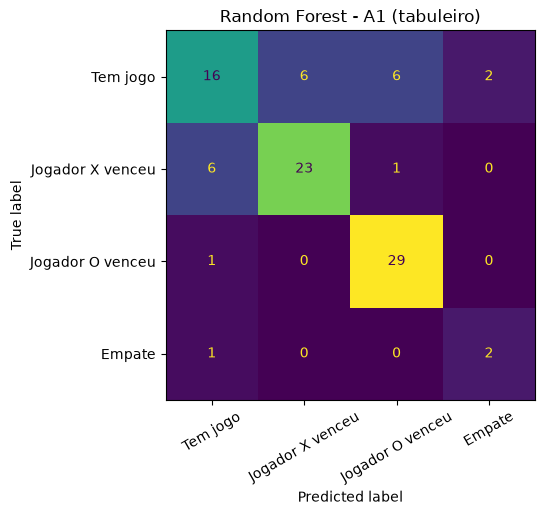

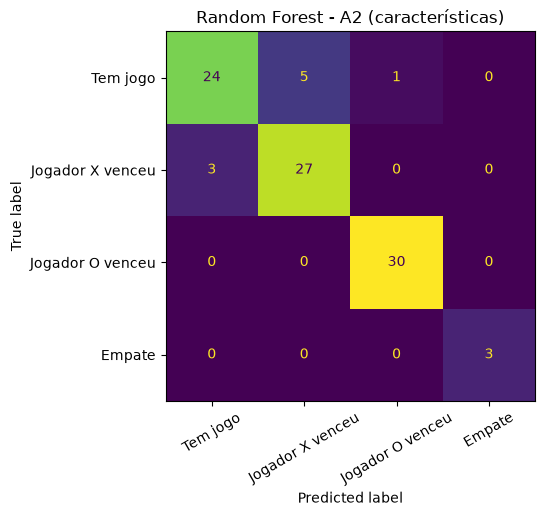

In [14]:
for ab in abordagens:
    resultado = confusion_matrix(dados[ab]["y_test"], previsoes[ab], labels=CLASSES)
    ConfusionMatrixDisplay(resultado, display_labels=CLASSES).plot(xticks_rotation=30, colorbar=False)
    plt.title(f"Random Forest - {abordagens[ab]}")
    figuras[f"matriz_confusao_{ab}"] = plt.gcf()
    plt.show()

## 8. Treino e validação em função de número de árvores

Para cada valor do parâmetro, selecionamos a configuração pelo F1 macro de
validação e pela acurácia, mantendo a ordem da grade no último desempate.
Mostramos treino e validação **da mesma configuração**, preservando a associação
entre as métricas. Uma diferença acentuada pode indicar sobreajuste e deve
ser analisada com os resultados por classe.

O gráfico descreve a busca de parâmetros; não é uma curva por épocas e não
garante que aumentar o parâmetro sempre melhore ou estabilize o resultado.

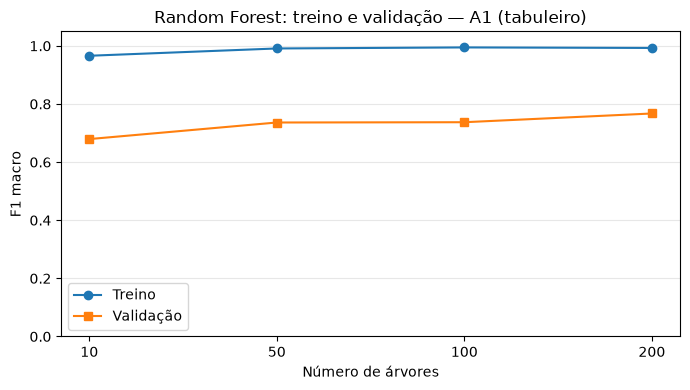

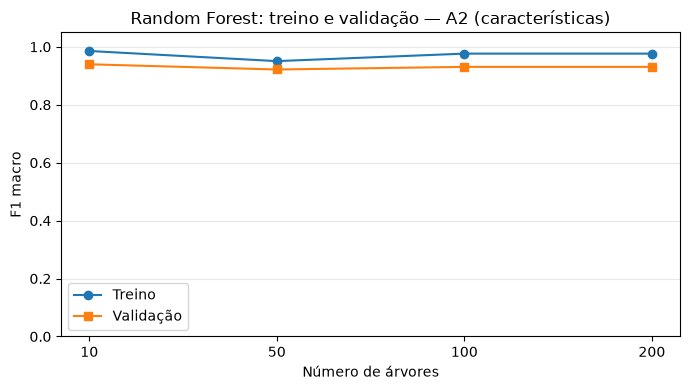

In [15]:
for ab in abordagens:
    s = resultados.loc[resultados["abordagem"] == abordagens[ab]].copy()
    # Ordenação estável preserva o desempate da grade, inclusive para None.
    s = s.sort_values(["val_f1_macro", "val_acc"], ascending=False, kind="stable")
    s = s.drop_duplicates("n_arvores").sort_values("n_arvores", na_position="last")
    rotulos = [str(int(v)) for v in s["n_arvores"]]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(len(s)), s["f1_treino"], marker="o", label="Treino")
    ax.plot(range(len(s)), s["val_f1_macro"], marker="s", label="Validação")
    ax.set_xticks(range(len(s)), rotulos)
    ax.set_xlabel("Número de árvores")
    ax.set_ylabel("F1 macro")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Random Forest: treino e validação — {abordagens[ab]}")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    figuras[f"treino_validacao_{ab}"] = fig
    plt.show()

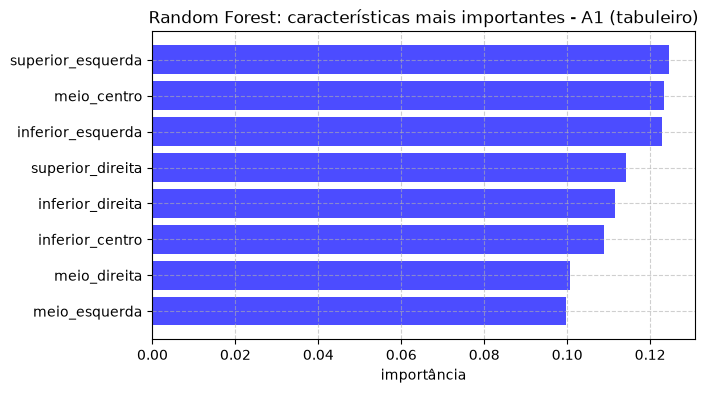

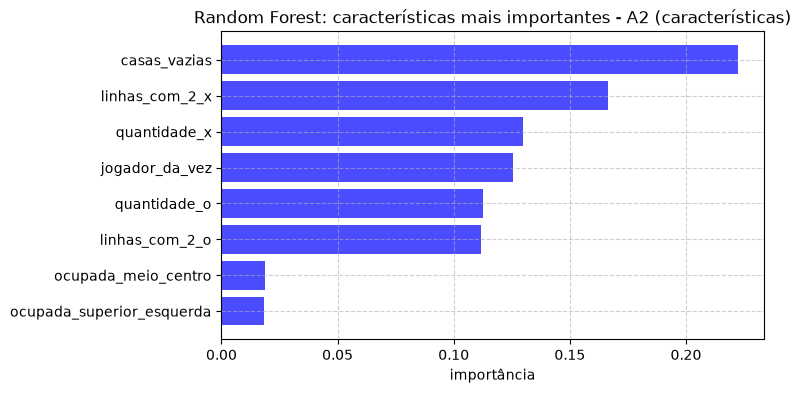

In [16]:
# importância das características (as 8 mais importantes de cada abordagem)
for ab in abordagens:
    modelo = melhor[ab]["modelo"]
    imp = pd.Series(modelo.feature_importances_, index=dados[ab]["X_train"].columns).sort_values(ascending=False).head(8)
    plt.figure(figsize=(7, 4))
    plt.barh(imp.index[::-1], imp.values[::-1], color="blue", alpha=0.7)
    plt.xlabel("importância")
    plt.title(f"Random Forest: características mais importantes - {abordagens[ab]}")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

## 9. Comparação das abordagens A1 e A2

Comparamos qualidade e custo das configurações selecionadas. A diferença entre
treino e validação utiliza a mesma configuração em ambos os conjuntos. Mais
características não garantem maior custo nem melhor generalização: o resultado
também depende dos parâmetros e do algoritmo.

A análise escrita está na seção seguinte. A comparação dos cinco algoritmos
está no [notebook de comparação](../comparacao/comparacao_classificadores.ipynb).

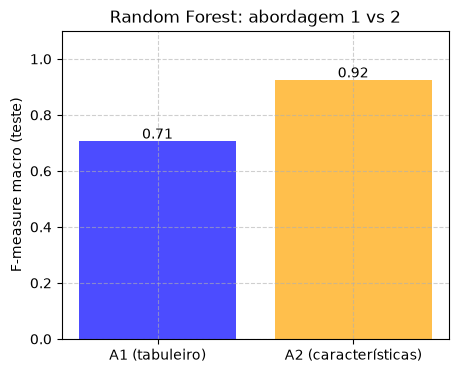

In [17]:
plt.figure(figsize=(5, 4))
plt.bar(tabela["abordagem"], tabela["f1_macro"], color=["blue", "orange"], alpha=0.7)
for i, v in enumerate(tabela["f1_macro"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("F-measure macro (teste)")
plt.title("Random Forest: abordagem 1 vs 2")
plt.grid(True, linestyle="--", alpha=0.6)
figuras["f1_teste"] = plt.gcf()
plt.show()

In [18]:
tabela[["abordagem", "acuracia", "f1_macro", "gap_treino_val", "tempo_treino_ms", "tempo_pred_ms"]].round(3)

,abordagem,acuracia,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.753,0.706,0.226,131.324,6.066
1,A2 (características),0.903,0.924,0.046,6.839,0.581


## 10. Análise dos resultados e conclusão

O texto utiliza os resultados desta execução: configuração, F1 de treino/validação/teste,
acurácia, custo e recomendação pela validação. Uma diferença grande entre treino e
validação pode indicar sobreajuste; uma diferença pequena não demonstra sua ausência.

A conclusão considera os poucos empates e a perda de informação de A2. A escolha
entre os cinco algoritmos está no [notebook de comparação](../comparacao/comparacao_classificadores.ipynb).

In [19]:
COMPLEMENTO_CONCLUSAO = '\n\n**Interpretação:** A1 selecionou 200 árvores sem limite de profundidade e pelo menos dois registros por folha; A2 selecionou 10 árvores sem limite e um registro por folha. O maior conjunto de árvores de A1 não produziu a melhor validação. A2 reduziu a diferença treino–validação e melhorou o teste, com menor custo de ajuste nesta execução. O ganho depende conjuntamente da representação e das configurações; não deve ser atribuído somente ao número de árvores. Uma floresta não supera necessariamente uma árvore isolada.'

ab_escolhida = max(abordagens, key=lambda ab: melhor[ab]["chave"])
conclusoes = []
for ab in abordagens:
    t = tabela.loc[tabela["codigo_abordagem"] == ab].iloc[0]
    empates = classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES,
                                    output_dict=True, zero_division=0)["Empate"]
    conclusoes.append(
        f"**{abordagens[ab]}:** configuração {melhor[ab]['params']}. "
        f"F1 macro: treino {t['f1_treino']:.3f}, validação {t['val_f1_macro']:.3f}, "
        f"teste {t['f1_macro']:.3f}; acurácia no teste {t['acuracia']:.2%}. "
        f"Diferença treino–validação: {t['gap_treino_val']:.3f}. "
        f"Treino médio {t['tempo_treino_ms']:.2f} ms; previsão do lote {t['tempo_pred_ms']:.3f} ms. "
        f"Reconheceu {int(round(empates['recall'] * empates['support']))} dos "
        f"{int(empates['support'])} empates do teste."
    )
t1, t2 = [tabela.loc[tabela["codigo_abordagem"] == ab].iloc[0] for ab in abordagens]
texto_conclusao = "\n\n".join(conclusoes)
texto_conclusao += (
    f"\n\n**Recomendação:** {abordagens[ab_escolhida]}, pelo F1 macro de validação "
    f"({melhor[ab_escolhida]['chave'][0]:.3f}) e pelos critérios de desempate declarados. "
    f"No teste, A2 superou A1 em {100 * (t2['f1_macro'] - t1['f1_macro']):.2f} "
    "pontos percentuais de F1 macro. Esse resultado descreve as configurações "
    "selecionadas; não prova que A2 seja melhor em qualquer amostra."
)
texto_conclusao += COMPLEMENTO_CONCLUSAO
texto_conclusao += (
    "\n\n**Custo e limitações:** as configurações de A1 e A2 podem ter complexidades "
    "diferentes. Interpretamos os tempos junto com seus parâmetros e a dispersão "
    "das medições. Há somente dois empates na validação e três no teste; a reamostragem "
    "não cria diversidade. A2 possui cinco grupos de entradas iguais com rótulos "
    "diferentes no treino. Possíveis simetrias entre divisões também limitam a análise."
)
display(Markdown(texto_conclusao))

**A1 (tabuleiro):** configuração {'n_arvores': 200, 'max_depth': None, 'min_leaf': 2}. F1 macro: treino 0.993, validação 0.767, teste 0.706; acurácia no teste 75.27%. Diferença treino–validação: 0.226. Treino médio 131.32 ms; previsão do lote 6.066 ms. Reconheceu 2 dos 3 empates do teste.

**A2 (características):** configuração {'n_arvores': 10, 'max_depth': None, 'min_leaf': 1}. F1 macro: treino 0.986, validação 0.940, teste 0.924; acurácia no teste 90.32%. Diferença treino–validação: 0.046. Treino médio 6.84 ms; previsão do lote 0.581 ms. Reconheceu 3 dos 3 empates do teste.

**Recomendação:** A2 (características), pelo F1 macro de validação (0.940) e pelos critérios de desempate declarados. No teste, A2 superou A1 em 21.86 pontos percentuais de F1 macro. Esse resultado descreve as configurações selecionadas; não prova que A2 seja melhor em qualquer amostra.

**Interpretação:** A1 selecionou 200 árvores sem limite de profundidade e pelo menos dois registros por folha; A2 selecionou 10 árvores sem limite e um registro por folha. O maior conjunto de árvores de A1 não produziu a melhor validação. A2 reduziu a diferença treino–validação e melhorou o teste, com menor custo de ajuste nesta execução. O ganho depende conjuntamente da representação e das configurações; não deve ser atribuído somente ao número de árvores. Uma floresta não supera necessariamente uma árvore isolada.

**Custo e limitações:** as configurações de A1 e A2 podem ter complexidades diferentes. Interpretamos os tempos junto com seus parâmetros e a dispersão das medições. Há somente dois empates na validação e três no teste; a reamostragem não cria diversidade. A2 possui cinco grupos de entradas iguais com rótulos diferentes no treino. Possíveis simetrias entre divisões também limitam a análise.

## 11. Exportação dos resultados e do modelo

Salvamos tabelas de configurações, métricas, treino/validação e custos das duas
abordagens. Previsões individuais, relatórios por classe, gráficos e conclusão
permitem reproduzir a análise no relatório sem extrair valores de imagens.

Exportamos somente o modelo da abordagem recomendada pela validação, incluindo
o padronizador do treino quando presente. Não há novo ajuste com validação ou teste.
O resumo registra versões, parâmetros e hashes dos CSVs.

In [20]:
import hashlib
import json
import platform

import joblib
import sklearn

ab_escolhida = max(abordagens, key=lambda ab: melhor[ab]["chave"])
modelo_exportado = melhor[ab_escolhida]["modelo"]
PASTA_RESULTADOS = BASE / "randomForest" / "resultados"
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

# Registrar ambas as abordagens, preservando a seleção pela validação.
linhas_predicoes, linhas_selecao = [], []
relatorios = {}
for ab in abordagens:
    d = dados[ab]
    linhas_predicoes.append(pd.DataFrame({
        "abordagem": ab, "id_tabuleiro": d["ids_test"].to_numpy(),
        "estado_real": d["y_test"], "estado_previsto": previsoes[ab],
        "acertou": d["y_test"] == previsoes[ab],
    }))
    relatorios[ab] = classification_report(d["y_test"], previsoes[ab], labels=CLASSES,
                                          output_dict=True, zero_division=0)
    linhas_selecao.append({
        "codigo_abordagem": ab, "abordagem": abordagens[ab],
        "f1_treino": melhor[ab]["f1_treino"], "val_f1_macro": melhor[ab]["chave"][0],
        "val_acc": melhor[ab]["chave"][1],
        "gap_treino_val": melhor[ab]["f1_treino"] - melhor[ab]["chave"][0],
        "n_features": d["X_train"].shape[1], **melhor[ab]["params"],
    })
pd.concat(linhas_predicoes, ignore_index=True).to_csv(PASTA_RESULTADOS / "previsoes_teste.csv", index=False)
pd.DataFrame(linhas_selecao).to_csv(PASTA_RESULTADOS / "configuracoes_selecionadas.csv", index=False)
tabela.to_csv(PASTA_RESULTADOS / "metricas_teste.csv", index=False)
resultados.to_csv(PASTA_RESULTADOS / "busca_validacao.csv", index=False)
(PASTA_RESULTADOS / "relatorios_por_classe.json").write_text(json.dumps(relatorios, ensure_ascii=False, indent=2) + "\n")
(PASTA_RESULTADOS / "conclusao.md").write_text(texto_conclusao + "\n", encoding="utf-8")
for nome_figura, figura in figuras.items():
    figura.savefig(PASTA_RESULTADOS / f"{nome_figura}.png", dpi=150, bbox_inches="tight")
d_exportado = dados[ab_escolhida]
previsoes_exportadas = previsoes[ab_escolhida]

arquivos_entrada = [
    BASE / ab / f"{conjunto}.csv"
    for ab in abordagens
    for conjunto in ["treino", "validacao", "teste"]
]
resumo = {
    "algoritmo": "Random Forest", "semente": SEED,
    "versoes": {"python": platform.python_version(), "scikit_learn": sklearn.__version__,
                "pandas": pd.__version__, "joblib": joblib.__version__},
    "classes": CLASSES, "threads_blas": 1, "repeticoes_tempo": REPETICOES_TEMPO,
    "criterio_selecao_configuracao": "F1 macro de validação; acurácia; primeira configuração da grade",
    "criterio_selecao_abordagem": "F1 macro de validação; acurácia; primeira abordagem",
    "configuracoes_testadas": len(resultados),
    "abordagem_escolhida_pela_validacao": ab_escolhida,
    "configuracoes_selecionadas": {ab: info["params"] for ab, info in melhor.items()},
    "metricas_validacao": {
        ab: {"f1_macro": info["chave"][0], "acuracia": info["chave"][1]}
        for ab, info in melhor.items()
    },
    "features_modelo_exportado": list(d_exportado["X_train"].columns),
    "ordem_classes_modelo": list(map(str, modelo_exportado.classes_)),
    "metricas_teste_modelo_exportado": metricas(d_exportado["y_test"], previsoes_exportadas),
    "csvs_entrada_sha256": {
        str(caminho.relative_to(RAIZ)): hashlib.sha256(caminho.read_bytes()).hexdigest()
        for caminho in arquivos_entrada
    },
}
(PASTA_RESULTADOS / "resumo_experimento.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2) + "\n", encoding="utf-8",
)
joblib.dump(modelo_exportado, PASTA_RESULTADOS / "modelo_random_forest.joblib", compress=3)

print("Abordagem exportada:", abordagens[ab_escolhida])
print("Configuração:", melhor[ab_escolhida]["params"])
print("F1 macro de validação:", round(melhor[ab_escolhida]["chave"][0], 6))
print("Arquivos salvos em:", PASTA_RESULTADOS.relative_to(RAIZ))

Abordagem exportada: A2 (características)
Configuração: {'n_arvores': 10, 'max_depth': None, 'min_leaf': 1}
F1 macro de validação: 0.939686
Arquivos salvos em: dataset/processado/randomForest/resultados
